# Revenue Leakage & Customer Retention: Python Analysis

This notebook extends the SQL analysis (`sql/`) with questions SQL answers poorly:

1. **Do deeper discounts actually buy more sales, or just give margin away?**
2. **Is the rating drop from late deliveries real, or noise?** (statistical test)
3. **How does each group of new customers behave over time?** (cohort retention heatmap)

It reads the clean tables produced by `sql/06_dashboard_exports.sql`. Run `./run_all.sh` first.

In [1]:
from math import erfc, sqrt
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd

DATA = Path("../dashboard_data")
CHARTS = Path("../outputs/charts")
CHARTS.mkdir(parents=True, exist_ok=True)

# Palette: one default color; orange = "focus here"; red = "problem"; green = "good".
BLUE, ORANGE, RED, GREEN = "#2a78d6", "#eb6834", "#d03b3b", "#0ca30c"
INK, INK_2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "font.family": "sans-serif", "font.size": 10,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "figure.facecolor": "white", "axes.facecolor": "white",
})

def money(x, pos=None):
    return f"${x/1e6:,.1f}M" if abs(x) >= 1e6 else f"${x:,.0f}"

orders = pd.read_csv(DATA / "fact_orders.csv", parse_dates=["order_date"])
customers = pd.read_csv(DATA / "dim_customers.csv", parse_dates=["first_order", "last_order"])
completed = orders[orders.order_status == "Completed"].copy()
print(f"{len(orders):,} orders | {len(completed):,} completed | {len(customers):,} customers")

138,116 orders | 113,559 completed | 25,000 customers


## 1. Sanity check against the SQL results

Before any new analysis, confirm pandas reproduces the SQL figures. If these don't match, nothing below can be trusted.

In [2]:
checks = pd.Series({
    "Booked revenue": orders.net_sales.sum(),
    "Completed revenue": completed.net_sales.sum(),
    "Collected revenue": orders.loc[orders.is_collected == 1, "net_sales"].sum(),
    "Completed profit": completed.profit.sum(),
})
expected = pd.Series({
    "Booked revenue": 177_134_263.74, "Completed revenue": 144_195_838.50,
    "Collected revenue": 129_905_000, "Completed profit": 59_758_469.03,
})
assert np.allclose(checks, expected, rtol=0.001), "pandas and SQL disagree"
checks.map(money)

Booked revenue       $177.1M
Completed revenue    $144.2M
Collected revenue    $129.9M
Completed profit      $59.8M
dtype: object

**One more data issue found here:** `net_sales` includes tax and shipping (`net = gross − discount + tax + shipping`). Reported "revenue" therefore includes money that belongs to the tax authority and the carrier.

In [3]:
raw = pd.read_csv("../data/ecommerce_sales_customer_analytics_150k.csv",
                  usecols=["order_status", "tax_amount", "shipping_cost"])
recon = orders.gross_sales - orders.discount_amount + raw.tax_amount + raw.shipping_cost
print(f"Rows where net_sales = gross - discount + tax + shipping: {np.isclose(recon, orders.net_sales, atol=0.05).mean():.1%}")
done = raw[raw.order_status == "Completed"]
print(f"Tax + shipping inside completed 'revenue': {money(done.tax_amount.sum() + done.shipping_cost.sum())}")

Rows where net_sales = gross - discount + tax + shipping: 100.0%
Tax + shipping inside completed 'revenue': $16.3M


## 2. Where booked revenue goes

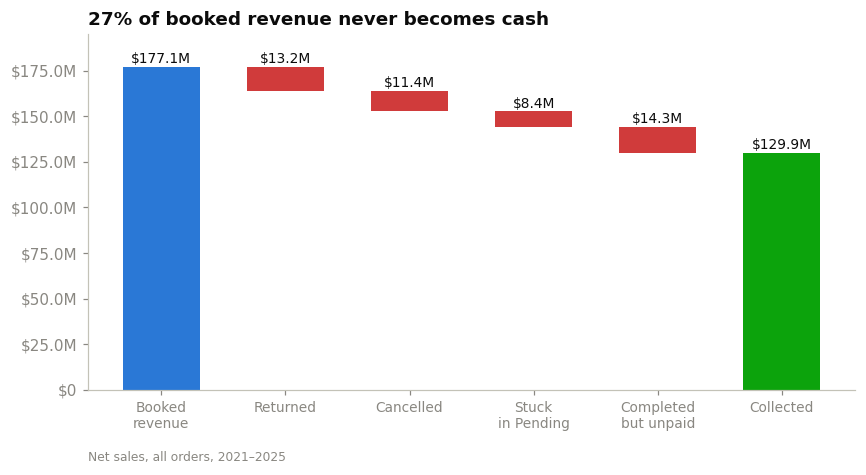

In [4]:
stages = [
    ("Booked revenue", orders.net_sales.sum()),
    ("Returned", -orders.loc[orders.order_status == "Returned", "net_sales"].sum()),
    ("Cancelled", -orders.loc[orders.order_status == "Cancelled", "net_sales"].sum()),
    ("Stuck in Pending", -orders.loc[orders.order_status == "Pending", "net_sales"].sum()),
    ("Completed but unpaid", -orders.loc[orders.is_unpaid_completed == 1, "net_sales"].sum()),
]
collected = sum(v for _, v in stages)
stages.append(("Collected", collected))

fig, ax = plt.subplots(figsize=(9, 4.2))
running = 0
for i, (label, value) in enumerate(stages):
    if label in ("Booked revenue", "Collected"):
        bottom, height, color = 0, value, BLUE if label == "Booked revenue" else GREEN
    else:
        bottom, height, color = running + value, -value, RED
    ax.bar(i, height, bottom=bottom, color=color, width=0.62)
    ax.text(i, bottom + height + 2e6, money(abs(value)), ha="center", color=INK, fontsize=9)
    if label == "Booked revenue":
        running = value
    elif label != "Collected":
        running += value
ax.set_xticks(range(len(stages)), [s.replace(" ", "\n", 1) if len(s) > 12 else s for s, _ in stages], fontsize=9)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(money))
ax.set_ylim(0, 195e6)
share_lost = 1 - collected / stages[0][1]
ax.set_title(f"{share_lost:.0%} of booked revenue never becomes cash")
ax.text(0, -0.2, "Net sales, all orders, 2021–2025", transform=ax.transAxes, color=MUTED, fontsize=8)
fig.savefig(CHARTS / "01_revenue_waterfall.png")
plt.show()

## 3. Do deeper discounts pay off?

The SQL analysis showed margin collapsing above a 35% discount. The question a pricing manager will ask: *"But don't those discounts bring in bigger orders?"*

In [5]:
by_band = completed.groupby("discount_band").agg(
    orders=("order_id", "size"),
    avg_items=("quantity", "mean"),
    avg_gross=("gross_sales", "mean"),
    avg_profit=("profit", "mean"),
).round(2)
by_band

,orders,avg_items,avg_gross,avg_profit
discount_band,,,,
1. 0-5%,9652,4.16,1095.65,601.87
2. 5-15%,50450,5.23,1257.45,603.96
3. 15-25%,29412,5.32,1298.06,491.85
4. 25-35%,12536,7.80,1911.66,502.79
5. 35%+,11509,7.85,1979.89,235.45


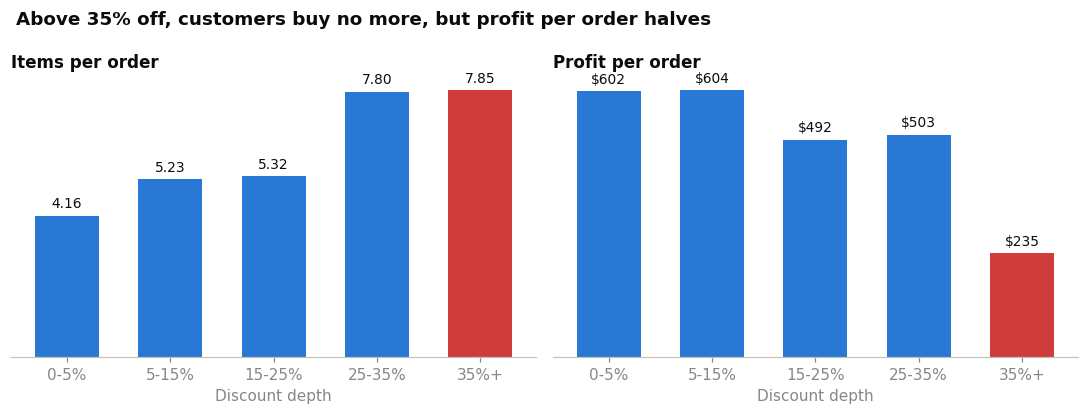

In [6]:
colors = [RED if b.startswith("5.") else BLUE for b in by_band.index]
labels = [b.split(". ")[1] for b in by_band.index]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for ax, col, title, fmt in [
    (axes[0], "avg_items", "Items per order", "{:.2f}"),
    (axes[1], "avg_profit", "Profit per order", "${:,.0f}"),
]:
    bars = ax.bar(labels, by_band[col], color=colors, width=0.62)
    ax.bar_label(bars, [fmt.format(v) for v in by_band[col]], padding=3, color=INK, fontsize=9)
    ax.set_title(title, fontsize=11)
    ax.set_yticks([])
    ax.spines["left"].set_visible(False)
    ax.set_xlabel("Discount depth", color=MUTED)
fig.suptitle("Above 35% off, customers buy no more, but profit per order halves",
             x=0.02, ha="left", fontsize=12, fontweight="bold", color=INK)
fig.tight_layout()
fig.savefig(CHARTS / "02_discount_effect.png")
plt.show()

Do discounts at least buy loyalty? Compare repeat rates by the discount on each customer's **first** order.

In [7]:
c = completed.sort_values("order_date")
first = c.groupby("customer_id").head(1)
first = first[first.order_date < "2025-01-01"]            # need a full year to observe a repeat
m = c.merge(first[["customer_id", "order_date"]], on="customer_id", suffixes=("", "_first"))
gap = (m.order_date - m.order_date_first).dt.days
repeaters = m.loc[(gap > 0) & (gap <= 365), "customer_id"].unique()
first = first.assign(repeat_within_1y=first.customer_id.isin(repeaters))
first.groupby("discount_band").repeat_within_1y.agg(repeat_rate="mean", customers="size").round(3)

,repeat_rate,customers
discount_band,,
1. 0-5%,0.610,2302
2. 5-15%,0.598,11887
3. 15-25%,0.603,6289
4. 25-35%,0.602,2141
5. 35%+,0.602,1730


**Finding.** Up to 35%, deeper discounts do grow the basket (5.2 → 7.8 items). **Beyond 35%, basket size stays flat (7.80 vs 7.85 items) while profit per order drops from ~$503 to ~$235.** The first-order discount also has no effect on whether the customer comes back (~60% in every band).

→ Discounts above 35% are pure margin giveaway. This makes the 20% volume-loss assumption in the discount-cap scenario look conservative.

## 4. Late deliveries and ratings: is the gap real?

Delayed: 3.22★ (n=16,886) | On time: 3.73★ (n=86,916)
Difference: -0.50★  |  95% CI: [-0.51, -0.49]  |  t = -136.0, p < 0.001


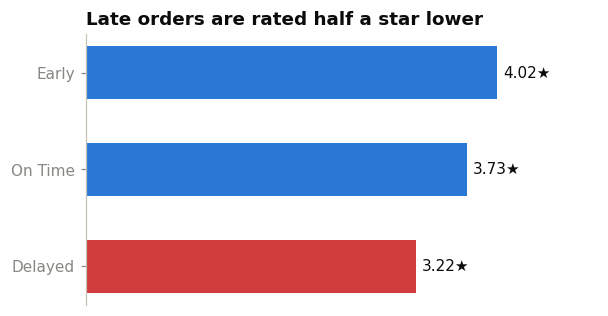

In [8]:
delayed = completed.loc[completed.delivery_status == "Delayed", "customer_rating"].dropna()
on_time = completed.loc[completed.delivery_status == "On Time", "customer_rating"].dropna()

# Welch's t-test (does not assume equal variances); normal approximation for p is exact enough at n > 15,000
diff = delayed.mean() - on_time.mean()
se = sqrt(delayed.var() / len(delayed) + on_time.var() / len(on_time))
t = diff / se
p = erfc(abs(t) / sqrt(2))
print(f"Delayed: {delayed.mean():.2f}★ (n={len(delayed):,}) | On time: {on_time.mean():.2f}★ (n={len(on_time):,})")
print(f"Difference: {diff:+.2f}★  |  95% CI: [{diff - 1.96*se:+.2f}, {diff + 1.96*se:+.2f}]  |  t = {t:.1f}, p < 0.001" if p < 0.001 else f"p = {p:.3f}")

rating = completed.groupby("delivery_status").customer_rating.mean().reindex(["Early", "On Time", "Delayed"])
fig, ax = plt.subplots(figsize=(6, 3.2))
bars = ax.barh(rating.index, rating.values, color=[BLUE, BLUE, RED], height=0.55)
ax.bar_label(bars, [f"{v:.2f}★" for v in rating.values], padding=4, color=INK)
ax.set_xlim(0, 5)
ax.invert_yaxis()
ax.set_xticks([])
ax.spines["bottom"].set_visible(False)
ax.set_title("Late orders are rated half a star lower")
fig.savefig(CHARTS / "03_delivery_rating.png")
plt.show()

**Finding.** The 0.5★ gap is statistically significant (p < 0.001) and large. Delays are 15% of orders at every warehouse and on every shipping method, so the fix is carrier deadlines (SLAs), not one bad warehouse.

## 5. Cohort retention: do new customers stick?

Customers are grouped by the **quarter of their first completed order**. Each cell shows the % of that group who bought again *N* quarters later.

In [9]:
c = completed[["customer_id", "order_date"]].copy()
c["order_q"] = c.order_date.dt.to_period("Q")
c["cohort"] = c.groupby("customer_id").order_q.transform("min")
c["age_q"] = (c.order_q - c.cohort).apply(lambda d: d.n)

cohort_size = c.groupby("cohort").customer_id.nunique()
active = c.groupby(["cohort", "age_q"]).customer_id.nunique().unstack()
retention = active.div(cohort_size, axis=0)

keep = cohort_size[cohort_size >= 200].index          # small cohorts are too noisy to read
retention = retention.loc[keep, 1:12]
print("Customers per cohort:", cohort_size.loc[keep].to_dict())
retention.round(3)

Customers per cohort: {Period('2021Q1', 'Q-DEC'): 4292, Period('2021Q2', 'Q-DEC'): 3837, Period('2021Q3', 'Q-DEC'): 3266, Period('2021Q4', 'Q-DEC'): 3518, Period('2022Q1', 'Q-DEC'): 1728, Period('2022Q2', 'Q-DEC'): 1551, Period('2022Q3', 'Q-DEC'): 1291, Period('2022Q4', 'Q-DEC'): 1465, Period('2023Q1', 'Q-DEC'): 684, Period('2023Q2', 'Q-DEC'): 620, Period('2023Q3', 'Q-DEC'): 546, Period('2023Q4', 'Q-DEC'): 585, Period('2024Q1', 'Q-DEC'): 300, Period('2024Q2', 'Q-DEC'): 246, Period('2024Q4', 'Q-DEC'): 225}


age_q,1,2,3,4,5,6,7,8,9,10,11,12
cohort,,,,,,,,,,,,
2021Q1,0.185,0.204,0.267,0.165,0.192,0.193,0.258,0.162,0.190,0.197,0.262,0.173
2021Q2,0.212,0.250,0.170,0.185,0.191,0.263,0.176,0.176,0.199,0.260,0.167,0.191
2021Q3,0.258,0.180,0.179,0.201,0.255,0.169,0.193,0.189,0.268,0.178,0.185,0.202
2021Q4,0.167,0.189,0.195,0.275,0.175,0.190,0.203,0.254,0.166,0.193,0.202,0.255
2022Q1,0.167,0.181,0.288,0.182,0.185,0.190,0.262,0.167,0.182,0.182,0.262,0.168
2022Q2,0.175,0.245,0.166,0.186,0.199,0.263,0.182,0.203,0.194,0.286,0.170,0.182
2022Q3,0.236,0.177,0.182,0.201,0.246,0.169,0.177,0.190,0.244,0.159,0.179,0.177
2022Q4,0.155,0.187,0.202,0.253,0.167,0.183,0.190,0.262,0.171,0.195,0.178,0.238
2023Q1,0.199,0.199,0.254,0.171,0.184,0.165,0.251,0.162,0.177,0.200,0.216,NaN


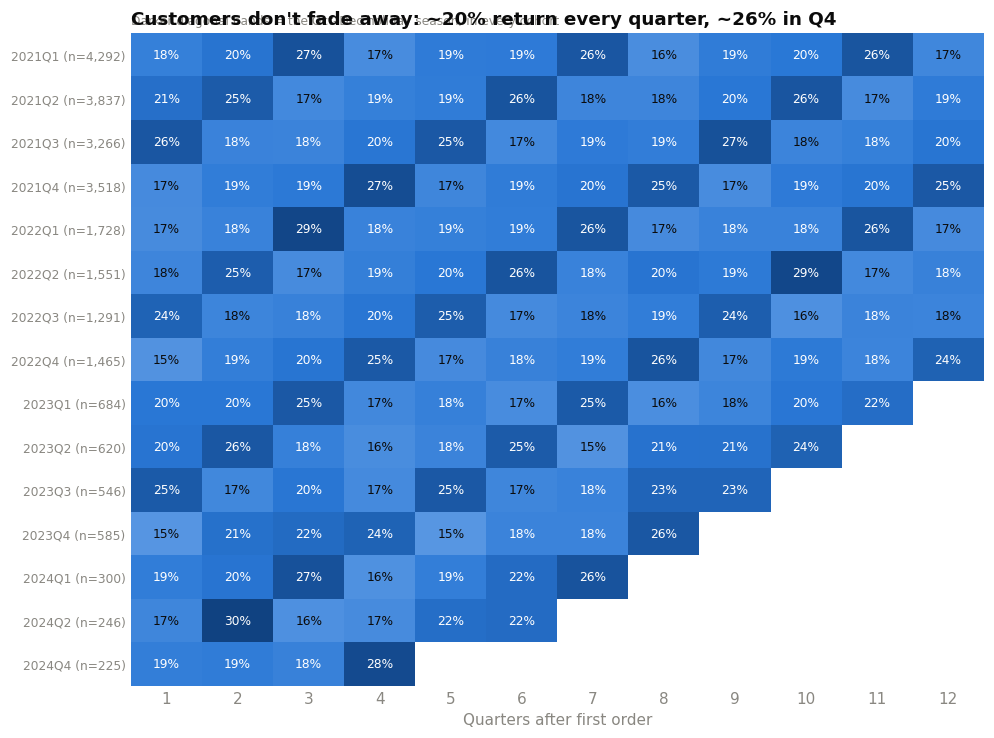

Average repeat rate, quarters 1–4: 20.3%


In [10]:
from matplotlib.colors import LinearSegmentedColormap
blues = LinearSegmentedColormap.from_list("blues", ["#cde2fb", "#86b6ef", "#2a78d6", "#104281"])

fig, ax = plt.subplots(figsize=(10, 0.42 * len(retention) + 1.4))
im = ax.imshow(retention.values, cmap=blues, aspect="auto", vmin=0, vmax=retention.max().max())
for (i, j), v in np.ndenumerate(retention.values):
    if not np.isnan(v):
        ax.text(j, i, f"{v:.0%}", ha="center", va="center", fontsize=8,
                color="white" if v > retention.max().max() * 0.6 else INK)
ax.set_xticks(range(retention.shape[1]), retention.columns)
ax.set_yticks(range(len(retention)), [f"{p} (n={cohort_size[p]:,})" for p in retention.index], fontsize=8)
ax.set_xlabel("Quarters after first order", color=MUTED)
ax.spines[:].set_visible(False)
ax.tick_params(length=0)
ax.set_title("Customers don't fade away: ~20% return every quarter, ~26% in Q4")
ax.text(0, 1.01, "Darker diagonal bands = the Oct–Dec holiday season, in every cohort", transform=ax.transAxes, color=MUTED, fontsize=8, va="bottom")
fig.savefig(CHARTS / "04_cohort_retention.png")
plt.show()

print(f"Average repeat rate, quarters 1–4: {retention.loc[:, 1:4].stack().mean():.1%}")

In [11]:
by_q = completed.groupby(completed.order_date.dt.quarter).net_sales.sum()
print((by_q / by_q.sum()).map("{:.0%}".format).rename("share of completed revenue"))

order_date
1    20%
2    22%
3    24%
4    34%
Name: share of completed revenue, dtype: object


**Finding.** Repeat buying doesn't decay with customer age. Every group returns at ~20% a quarter, even three years in. The dark diagonal is the **holiday season: Q4 brings in 34% of yearly revenue**. So customers are seasonal, not disloyal.

→ Time win-back campaigns for **September–October**, just before customers' natural buying peak, rather than spreading them across the year.

## 6. Customer segments (RFM) and revenue at risk

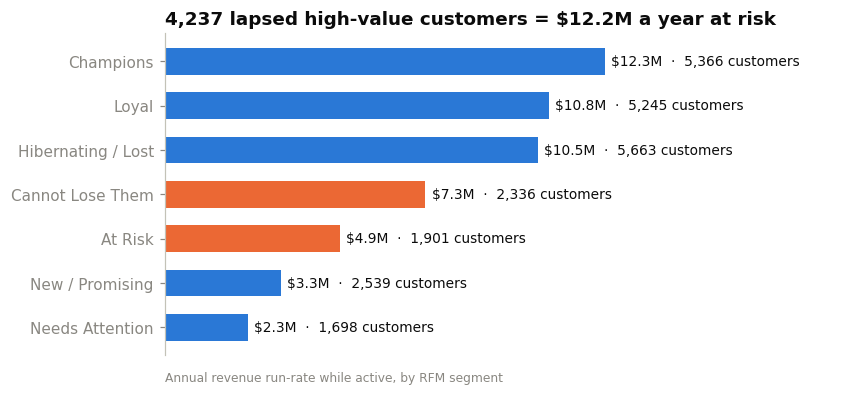

In [12]:
seg = (customers[customers.rfm_segment != "No Completed Orders"]
       .groupby("rfm_segment")
       .agg(customers=("customer_id", "size"), annual_revenue=("annual_revenue", "sum"))
       .sort_values("annual_revenue"))
focus = {"Cannot Lose Them", "At Risk"}

fig, ax = plt.subplots(figsize=(8, 3.8))
bars = ax.barh(seg.index, seg.annual_revenue, color=[ORANGE if s in focus else BLUE for s in seg.index], height=0.6)
ax.bar_label(bars, [f"{money(v)}  ·  {n:,} customers" for v, n in zip(seg.annual_revenue, seg.customers)],
             padding=4, color=INK, fontsize=9)
ax.set_xlim(0, seg.annual_revenue.max() * 1.55)
ax.set_xticks([])
ax.spines["bottom"].set_visible(False)
at_risk = seg.loc[list(focus)]
ax.set_title(f"{at_risk.customers.sum():,} lapsed high-value customers = {money(at_risk.annual_revenue.sum())} a year at risk")
ax.text(0, -0.08, "Annual revenue run-rate while active, by RFM segment", transform=ax.transAxes, color=MUTED, fontsize=8)
fig.savefig(CHARTS / "05_rfm_segments.png")
plt.show()

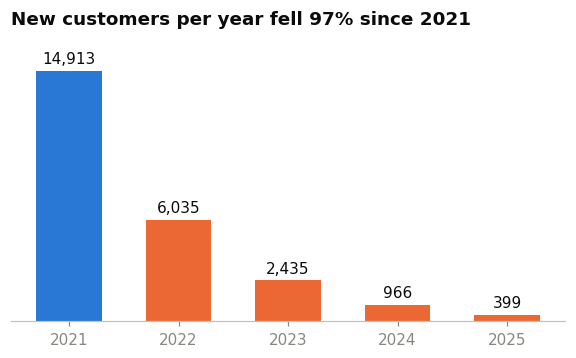

In [13]:
new_by_year = customers.dropna(subset=["first_order_year"]).groupby("first_order_year").size()
new_by_year.index = new_by_year.index.astype(int)

fig, ax = plt.subplots(figsize=(6.5, 3.4))
bars = ax.bar(new_by_year.index.astype(str), new_by_year.values,
              color=[BLUE] + [ORANGE] * (len(new_by_year) - 1), width=0.6)
ax.bar_label(bars, [f"{v:,}" for v in new_by_year.values], padding=3, color=INK)
ax.set_ylim(0, new_by_year.max() * 1.15)
ax.set_yticks([])
ax.spines["left"].set_visible(False)
drop = 1 - new_by_year.iloc[-1] / new_by_year.iloc[0]
ax.set_title(f"New customers per year fell {drop:.0%} since 2021")
fig.savefig(CHARTS / "06_new_customers.png")
plt.show()

## 7. What Python added to the SQL findings

| Question | Answer | Effect on recommendations |
|---|---|---|
| Do discounts above 35% buy more volume? | **No.** Same basket size as 25–35%, half the profit | Strengthens the 30% cap; the 20% volume-loss assumption is conservative |
| Do discounts buy loyalty? | **No.** ~60% repeat within a year in every discount band | Don't use deep first-order discounts as a retention tool |
| Is the late-delivery rating gap real? | **Yes.** −0.50★, p < 0.001 | Carrier deadlines are worth renegotiating |
| Do customers fade over time? | **No.** ~20% return every quarter; Q4 = 34% of revenue | Launch win-back campaigns in Sep–Oct, ahead of the peak |
| Is "revenue" clean? | **No.** It includes tax and shipping | Report revenue excluding tax and shipping |